<a href="https://colab.research.google.com/github/mahepMSFT/Python/blob/master/E_Commerce_Web_Scraping_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests beautifulsoup4 pandas matplotlib lxml -q

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

In [4]:
def scrape_products(url, brand_name):
    response = requests.get(url, headers=headers)
    print("Status Code:", response.status_code)

    soup = BeautifulSoup(response.text, "html.parser")

    # Change this selector based on the website structure
    product_cards = soup.find_all("div", class_="product-card")

    data = []

    for card in product_cards[:10]:
        # Title
        title_tag = card.find("h3")
        title = title_tag.get_text(strip=True) if title_tag else "N/A"

        # Price
        price_tag = card.find("span", class_="price")
        price_text = price_tag.get_text(strip=True) if price_tag else "N/A"

        # Offer / discount
        offer_tag = card.find("span", class_="offer")
        offer = offer_tag.get_text(strip=True) if offer_tag else "No Offer"

        # Product URL
        link_tag = card.find("a", href=True)
        product_url = link_tag["href"] if link_tag else "N/A"

        # Convert relative URL to full URL if needed
        if product_url != "N/A" and product_url.startswith("/"):
            base_url = "/".join(url.split("/")[:3])
            product_url = base_url + product_url

        # Convert price to numeric if possible
        numeric_price = re.sub(r"[^0-9.]", "", price_text)
        numeric_price = float(numeric_price) if numeric_price else None

        data.append({
            "Brand": brand_name,
            "Title": title,
            "Price_Text": price_text,
            "Price": numeric_price,
            "Offer": offer,
            "Product_URL": product_url
        })

    df = pd.DataFrame(data)
    return df

In [8]:
url_brand1 = "https://webscraper.io/test-sites/e-commerce/static/computers/laptops"
url_brand2 = "https://webscraper.io/test-sites/e-commerce/static/computers/tablets"

In [9]:
def scrape_webscraper_site(url, brand_name):
    response = requests.get(url, headers=headers)
    print(f"{brand_name} Status Code:", response.status_code)

    soup = BeautifulSoup(response.text, "html.parser")

    cards = soup.find_all("div", class_="thumbnail")
    data = []

    for card in cards[:10]:
        title_tag = card.find("a", class_="title")
        title = title_tag.get_text(strip=True) if title_tag else "N/A"

        price_tag = card.find("h4", class_="price")
        price_text = price_tag.get_text(strip=True) if price_tag else "N/A"

        # This demo site usually doesn't have offer text, so we create a placeholder
        offer = "No Offer Mentioned"

        product_url = title_tag["href"] if title_tag and title_tag.has_attr("href") else "N/A"
        if product_url != "N/A" and product_url.startswith("/"):
            product_url = "https://webscraper.io" + product_url

        numeric_price = re.sub(r"[^0-9.]", "", price_text)
        numeric_price = float(numeric_price) if numeric_price else None

        data.append({
            "Brand": brand_name,
            "Title": title,
            "Price_Text": price_text,
            "Price": numeric_price,
            "Offer": offer,
            "Product_URL": product_url
        })

    return pd.DataFrame(data)

In [10]:
df_brand1 = scrape_webscraper_site(
    "https://webscraper.io/test-sites/e-commerce/static/computers/laptops",
    "Brand_1"
)

df_brand2 = scrape_webscraper_site(
    "https://webscraper.io/test-sites/e-commerce/static/phones/touch",
    "Brand_2"
)

print("Brand 1 Data")
display(df_brand1)

print("Brand 2 Data")
display(df_brand2)

Brand_1 Status Code: 200
Brand_2 Status Code: 200
Brand 1 Data


,Brand,Title,Price_Text,Price,Offer,Product_URL
0,Brand_1,Packard 255 G2,$416.99,416.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
1,Brand_1,Aspire E1-510,$306.99,306.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
2,Brand_1,ThinkPad T540p,$1178.99,1178.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
3,Brand_1,ProBook,$739.99,739.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
4,Brand_1,ThinkPad X240,$1311.99,1311.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
5,Brand_1,Aspire E1-572G,$581.99,581.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...


Brand 2 Data


,Brand,Title,Price_Text,Price,Offer,Product_URL
0,Brand_2,Nokia 123,$24.99,24.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
1,Brand_2,LG Optimus,$57.99,57.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
2,Brand_2,Samsung Galaxy,$93.99,93.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
3,Brand_2,Nokia X,$109.99,109.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
4,Brand_2,Sony Xperia,$118.99,118.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
5,Brand_2,Ubuntu Edge,$499.99,499.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...


In [11]:
df_brand1.to_csv("brand1_products.csv", index=False)
df_brand2.to_csv("brand2_products.csv", index=False)

print("Files saved:")
print("brand1_products.csv")
print("brand2_products.csv")

Files saved:
brand1_products.csv
brand2_products.csv


In [12]:
combined_df = pd.concat([df_brand1, df_brand2], ignore_index=True)
display(combined_df)

,Brand,Title,Price_Text,Price,Offer,Product_URL
0,Brand_1,Packard 255 G2,$416.99,416.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
1,Brand_1,Aspire E1-510,$306.99,306.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
2,Brand_1,ThinkPad T540p,$1178.99,1178.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
3,Brand_1,ProBook,$739.99,739.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
4,Brand_1,ThinkPad X240,$1311.99,1311.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
5,Brand_1,Aspire E1-572G,$581.99,581.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
6,Brand_2,Nokia 123,$24.99,24.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
7,Brand_2,LG Optimus,$57.99,57.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
8,Brand_2,Samsung Galaxy,$93.99,93.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...
9,Brand_2,Nokia X,$109.99,109.99,No Offer Mentioned,https://webscraper.io/test-sites/e-commerce/st...


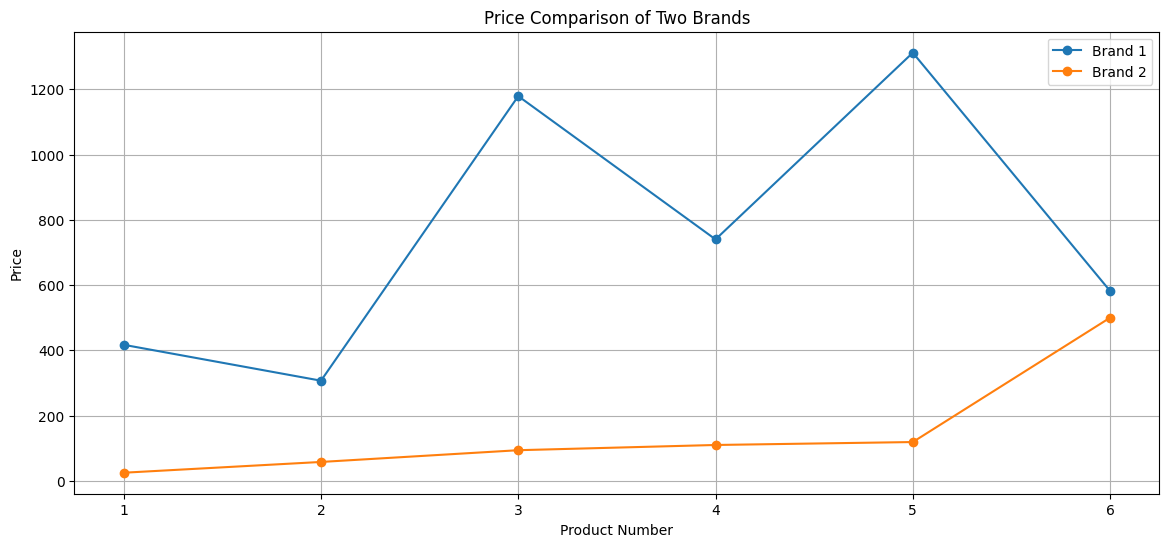

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(df_brand1.index + 1, df_brand1["Price"], marker="o", label="Brand 1")
plt.plot(df_brand2.index + 1, df_brand2["Price"], marker="o", label="Brand 2")

plt.xlabel("Product Number")
plt.ylabel("Price")
plt.title("Price Comparison of Two Brands")
plt.legend()
plt.grid(True)
plt.show()

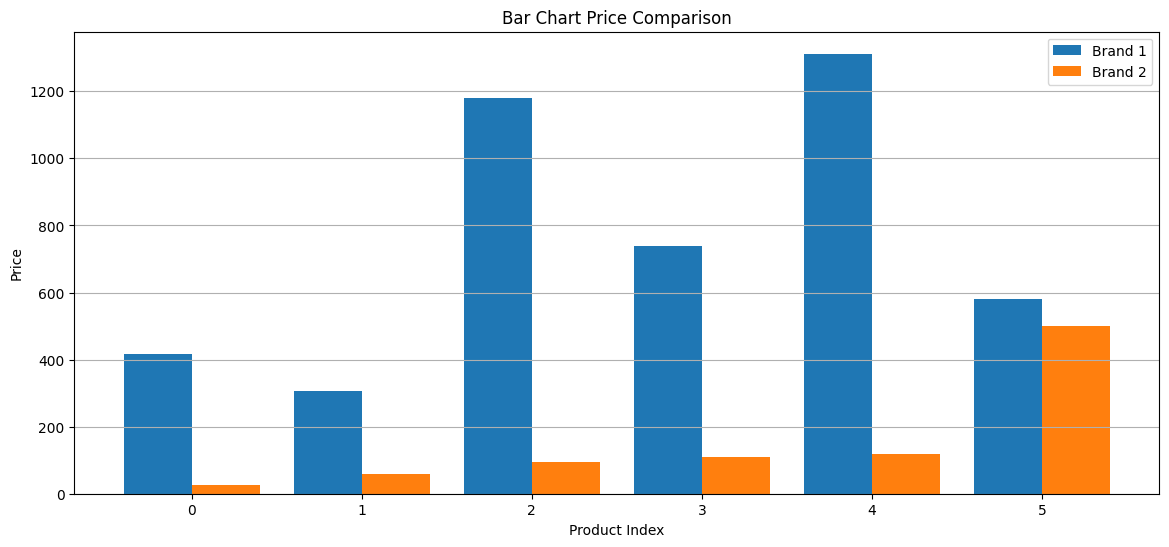

In [14]:
plt.figure(figsize=(14, 6))

x1 = range(len(df_brand1))
x2 = range(len(df_brand2))

plt.bar([i - 0.2 for i in x1], df_brand1["Price"], width=0.4, label="Brand 1")
plt.bar([i + 0.2 for i in x2], df_brand2["Price"], width=0.4, label="Brand 2")

plt.xlabel("Product Index")
plt.ylabel("Price")
plt.title("Bar Chart Price Comparison")
plt.legend()
plt.grid(axis="y")
plt.show()